# 第5章 大規模言語モデルのファインチューニング

**注意**
2023/7/28現在、MARC-jaのデータセットの配布元のリンクが切れており、書籍上の5.2、5.3、5.5.4節に掲載されているコードにおいて、データセット読み込みの箇所でエラーが出る状態です。こちらのノートブックは、MARC-jaと同様の感情分析のデータセットであるWRIMEを用いて書籍と同様のコードを実行するために用意されています。

## 5.5 メモリ効率の良いファインチューニング

### 5.5.4 LoRAチューニング

#### 環境の準備

In [ ]:
!pip install 'transformers[ja,torch]' 'datasets<4.0.0' matplotlib japanize-matplotlib peft

In [ ]:
from transformers.trainer_utils import set_seed

# 乱数シードを42に固定
set_seed(42)

#### データセットの準備

In [ ]:
from pprint import pprint
from datasets import load_dataset

# Hugging Face Hub上のllm-book/wrime-sentimentのリポジトリから
# データを読み込む
train_dataset = load_dataset("llm-book/wrime-sentiment", split="train")
valid_dataset = load_dataset("llm-book/wrime-sentiment", split="validation")
test_dataset = load_dataset("llm-book/wrime-sentiment", split="test")

# pprintで見やすく表示する
pprint(len(train_dataset))
pprint(len(valid_dataset))
pprint(len(test_dataset))

default/train/0000.parquet:   0%|          | 0.00/1.72M [00:00<?, ?B/s]

default/validation/0000.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

default/test/0000.parquet:   0%|          | 0.00/178k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20149 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1608 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1781 [00:00<?, ? examples/s]

20149
1608
1781


In [ ]:
pprint(train_dataset.features)

{'datetime': Value(dtype='string', id=None),
 'label': ClassLabel(names=['positive', 'negative'], id=None),
 'sentence': Value(dtype='string', id=None),
 'user_id': Value(dtype='int64', id=None)}


In [ ]:
import pandas as pd
# データセットの最初の1件を表示して、どのカラムが 'label' に割り当てられているか、
# あるいは他の感情関連カラム（客観/主観）がどうなっているか確認します。
display(pd.DataFrame([train_dataset[0]]))
print(f"\nDataset features: {train_dataset.features}")

,sentence,label,user_id,datetime
0,ぼけっとしてたらこんな時間。チャリあるから食べにでたいのに…,1,1,2012/7/31 23:48



Dataset features: {'sentence': Value(dtype='string', id=None), 'label': ClassLabel(names=['positive', 'negative'], id=None), 'user_id': Value(dtype='int64', id=None), 'datetime': Value(dtype='string', id=None)}


#### トークナイザ

In [ ]:
from transformers import AutoTokenizer

# Hugging Face Hub上のモデル名を指定
model_name = "google/gemma-3-1b-it"
# モデル名からトークナイザを読み込む
tokenizer = AutoTokenizer.from_pretrained(model_name)
# トークナイザのクラス名を確認
print(type(tokenizer).__name__)

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/4.69M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

GemmaTokenizerFast


In [ ]:
tokenizer.tokenize("これはテストです。")

['これは', 'テスト', 'です', '。']

In [ ]:
encoded_input = tokenizer("これはテストです。")
# 出力されたオブジェクトのクラスを表示
print(type(encoded_input).__name__)

BatchEncoding


In [ ]:
pprint(encoded_input)

{'attention_mask': [1, 1, 1, 1, 1],
 'input_ids': [2, 49834, 88733, 3652, 236924]}


In [ ]:
tokenizer.convert_ids_to_tokens(encoded_input["input_ids"])

['<bos>', 'これは', 'テスト', 'です', '。']

#### データセット統計の可視化

100%|██████████| 20149/20149 [00:07<00:00, 2677.64it/s]


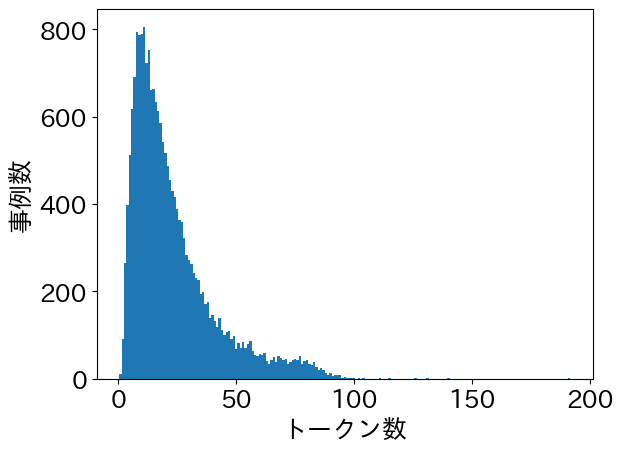

100%|██████████| 1608/1608 [00:00<00:00, 4566.29it/s]


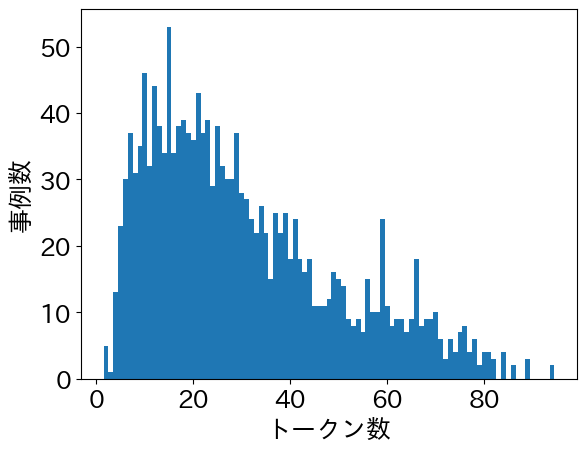

In [ ]:
from collections import Counter
import japanize_matplotlib
import matplotlib.pyplot as plt
from datasets import Dataset
from tqdm import tqdm

plt.rcParams["font.size"] = 18  # 文字サイズを大きくする

def visualize_text_length(dataset: Dataset):
    """データセット中のテキストのトークン数の分布をグラフとして描画"""
    # データセット中のテキストの長さを数える
    length_counter = Counter()
    for data in tqdm(dataset):
        length = len(tokenizer.tokenize(data["sentence"]))
        length_counter[length] += 1
    # length_counterの値から棒グラフを描画する
    plt.bar(length_counter.keys(), length_counter.values(), width=1.0)
    plt.xlabel("トークン数")
    plt.ylabel("事例数")
    plt.show()

visualize_text_length(train_dataset)
visualize_text_length(valid_dataset)

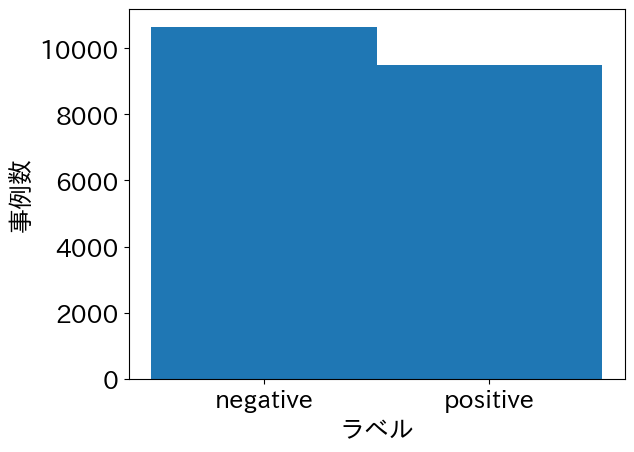

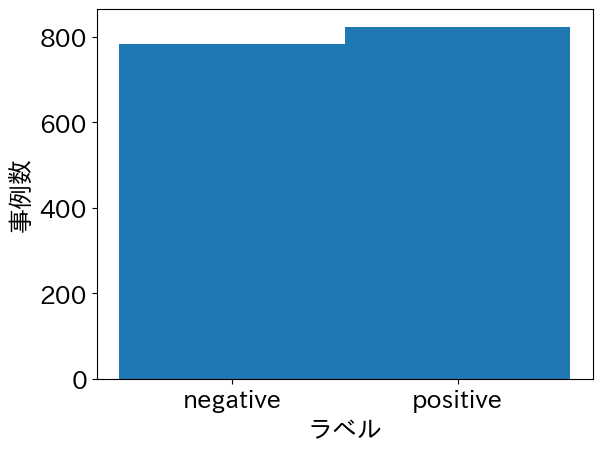

In [ ]:
def visualize_labels(dataset: Dataset):
    """データセット中のラベル分布をグラフとして描画"""
    # データセット中のラベルの数を数える
    label_counter = Counter()
    for data in dataset:
        label_id = data["label"]
        label_name = dataset.features["label"].names[label_id]
        label_counter[label_name] += 1
    # label_counterを棒グラフとして描画する
    plt.bar(label_counter.keys(), label_counter.values(), width=1.0)
    plt.xlabel("ラベル")
    plt.ylabel("事例数")
    plt.show()

visualize_labels(train_dataset)
visualize_labels(valid_dataset)

#### データセットの前処理

In [ ]:
from transformers import BatchEncoding

def preprocess_text_classification(
    example: dict[str, str | int]
) -> BatchEncoding:
    """文書分類の事例のテキストをトークナイズし、IDに変換"""
    encoded_example = tokenizer(example["sentence"], max_length=512)
    # モデルの入力引数である"labels"をキーとして格納する
    encoded_example["labels"] = example["label"]
    return encoded_example

In [ ]:
encoded_train_dataset = train_dataset.map(
    preprocess_text_classification,
    remove_columns=train_dataset.column_names,
)
encoded_valid_dataset = valid_dataset.map(
    preprocess_text_classification,
    remove_columns=valid_dataset.column_names,
)

Map:   0%|          | 0/20149 [00:00<?, ? examples/s]

Truncation was not explicitly activated but `max_length` is provided a specific value, please use `truncation=True` to explicitly truncate examples to max length. Defaulting to 'longest_first' truncation strategy. If you encode pairs of sequences (GLUE-style) with the tokenizer you can select this strategy more precisely by providing a specific strategy to `truncation`.


Map:   0%|          | 0/1608 [00:00<?, ? examples/s]

In [ ]:
print(encoded_train_dataset[0])

{'input_ids': [2, 240092, 237406, 237132, 12547, 56058, 57887, 13413, 236924, 20599, 237207, 6466, 5077, 37815, 237000, 237007, 19203, 46468, 237064], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': 1}


#### ミニバッチ構築

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [ ]:
batch_inputs = data_collator(encoded_train_dataset[0:4])
pprint({name: tensor.size() for name, tensor in batch_inputs.items()})

{'attention_mask': torch.Size([4, 33]),
 'input_ids': torch.Size([4, 33]),
 'labels': torch.Size([4])}


#### モデルの準備

In [ ]:
from transformers import AutoModelForSequenceClassification

class_label = train_dataset.features["label"]
label2id = {label: id for id, label in enumerate(class_label.names)}
id2label = {id: label for id, label in enumerate(class_label.names)}
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=class_label.num_classes,
    label2id=label2id,  # ラベル名からIDへの対応を指定
    id2label=id2label,  # IDからラベル名への対応を指定
)
print(type(base_model).__name__)

config.json:   0%|          | 0.00/899 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.00G [00:00<?, ?B/s]

Some weights of Gemma3TextForSequenceClassification were not initialized from the model checkpoint at google/gemma-3-1b-it and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Gemma3TextForSequenceClassification


In [ ]:
import peft

peft_config = peft.LoraConfig(
    task_type=peft.TaskType.SEQ_CLS,  # モデルが解くタスクのタイプを指定
    r=8,  # 差分行列のランク
    lora_alpha=32,  #  LoRA層の出力のスケールを調節するハイパーパラメータ
    lora_dropout=0.1,  # LoRA層に適用するドロップアウト
    inference_mode=False,  # 推論モードの設定（今回は学習時なのでFalse）
)
model = peft.get_peft_model(base_model, peft_config)
print(type(model).__name__)

PeftModelForSequenceClassification


In [ ]:
model.print_trainable_parameters()
# base_model.print_trainable_parameters()

NameError: name 'model' is not defined

In [ ]:
print(model.forward(**data_collator(encoded_train_dataset[0:4])))

SequenceClassifierOutputWithPast(loss=tensor(5.5976, grad_fn=<NllLossBackward0>), logits=tensor([[ 1.9625, -4.8451],
        [ 0.9079, -4.1793],
        [ 3.2815, -4.1355],
        [ 2.3511, -5.8065]], grad_fn=<IndexBackward0>), past_key_values=DynamicCache(layers=[DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicLayer]), hidden_states=None, attentions=None)


#### 訓練の実行

In [ ]:
from transformers import TrainingArguments

lora_training_args = TrainingArguments(
    output_dir="output_wrime_lora",  # 結果の保存フォルダ
    per_device_train_batch_size=32,  # 訓練時のバッチサイズ
    per_device_eval_batch_size=32,  # 評価時のバッチサイズ
    learning_rate=2e-4,  # 学習率
    lr_scheduler_type="linear",  # 学習率スケジューラの種類
    warmup_ratio=0.1,  # 学習率のウォームアップの長さを指定
    num_train_epochs=3,  # エポック数
    save_strategy="epoch",  # チェックポイントの保存タイミング
    logging_strategy="epoch",  # ロギングのタイミング
    eval_strategy="epoch",  # 検証セットによる評価のタイミング
    load_best_model_at_end=True,  # 訓練後に開発セットで最良のモデルをロード
    metric_for_best_model="accuracy",  # 最良のモデルを決定する評価指標
    fp16=True,  # 自動混合精度演算の有効化
    report_to="none",  # 外部ツールへのログを無効化
)

full_training_args = TrainingArguments(
    output_dir="output_wrime_full_1b",  # 結果の保存フォルダ
    per_device_train_batch_size=32,  # 訓練時のバッチサイズ
    per_device_eval_batch_size=32,  # 評価時のバッチサイズ
    learning_rate=2e-5,  # 学習率
    lr_scheduler_type="linear",  # 学習率スケジューラの種類
    warmup_ratio=0.1,  # 学習率のウォームアップの長さを指定
    num_train_epochs=3,  # エポック数
    save_strategy="epoch",  # チェックポイントの保存タイミング
    logging_strategy="epoch",  # ロギングのタイミング
    eval_strategy="epoch",  # 検証セットによる評価のタイミング
    load_best_model_at_end=True,  # 訓練後に開発セットで最良のモデルをロード
    metric_for_best_model="accuracy",  # 最良のモデルを決定する評価指標
    fp16=True,  # 自動混合精度演算の有効化
    report_to="none",  # 外部ツールへのログを無効化
)

In [ ]:
import numpy as np

def compute_accuracy(
    eval_pred: tuple[np.ndarray, np.ndarray]
) -> dict[str, float]:
    """予測ラベルと正解ラベルから正解率を計算"""
    predictions, labels = eval_pred
    # predictionsは各ラベルについてのスコア
    # 最もスコアの高いインデックスを予測ラベルとする
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": (predictions == labels).mean()}

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=data_collator,
    args=lora_training_args,
    compute_metrics=compute_accuracy,
)
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.548100,0.256791,0.900498
2,0.237100,0.239377,0.906716
3,0.178900,0.232990,0.911692


TrainOutput(global_step=1890, training_loss=0.32137795907479744, metrics={'train_runtime': 520.1007, 'train_samples_per_second': 116.222, 'train_steps_per_second': 3.634, 'total_flos': 2781626664702720.0, 'train_loss': 0.32137795907479744, 'epoch': 3.0})

In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=base_model,
    train_dataset=encoded_train_dataset,
    eval_dataset=encoded_valid_dataset,
    data_collator=data_collator,
    args=full_training_args,
    compute_metrics=compute_accuracy,
)
trainer.train()

OutOfMemoryError: CUDA out of memory. Tried to allocate 32.00 MiB. GPU 0 has a total capacity of 14.74 GiB of which 22.12 MiB is free. Process 11647 has 14.72 GiB memory in use. Of the allocated memory 13.89 GiB is allocated by PyTorch, and 711.58 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://pytorch.org/docs/stable/notes/cuda.html#environment-variables)

#### 訓練後のモデルの評価

In [ ]:
# 検証セットでモデルを評価
eval_metrics = trainer.evaluate(encoded_valid_dataset)
pprint(eval_metrics)

{'epoch': 3.0,
 'eval_accuracy': 0.9148009950248757,
 'eval_loss': 0.5105249285697937,
 'eval_runtime': 4.4759,
 'eval_samples_per_second': 359.255,
 'eval_steps_per_second': 11.394}


### LoRAモデルの呼び出しと推論

まず、ファインチューニングに使用したベースモデルと同じ設定でモデルとトークナイザーを読み込みます。次に、訓練済みのLoRAアダプターをベースモデルにロードし、必要に応じてマージして推論を実行します。

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from peft import PeftModel
import torch

model_name = "google/gemma-3-270m-it"
lora_model_path = "output_wrime_lora/checkpoint-1890"
full_model_path = "output_wrime_full/checkpoint-1890"

id2label = {0: 'positive', 1: 'negative'}
label2id = {'positive': 0, 'negative': 1}

tokenizer = AutoTokenizer.from_pretrained(model_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---
# 1. 【先に】LoRAマージ済みモデルを作成する
# ---
# まずベースモデルをロード（これは lora_model 作成用）
temp_base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
)
# LoRAアダプタをマージして、lora_model として完成させる
lora_model = PeftModel.from_pretrained(temp_base_model, lora_model_path)
lora_model = lora_model.merge_and_unload()
lora_model.to(device)
lora_model.eval()

# (temp_base_model はもう不要なら削除してもよい)
# del temp_base_model

# ---
# 2. 【改めて】まっさらなベースモデルをロードし直す
# ---
# 完全に別物として、もう一度ベースモデルをロードする
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
)
base_model.to(device)
base_model.eval()

# full ft
full_model = AutoModelForSequenceClassification.from_pretrained(
    full_model_path,
    num_labels=len(id2label),
    id2label=id2label,
    label2id=label2id,
)
full_model.to(device)
full_model.eval()

print(f"base_model と lora_model と　full_model を {device} に別々にロードしました。")

Some weights of Gemma3TextForSequenceClassification were not initialized from the model checkpoint at google/gemma-3-270m-it and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of Gemma3TextForSequenceClassification were not initialized from the model checkpoint at google/gemma-3-270m-it and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


base_model と lora_model と　full_model を cuda に別々にロードしました。


### テキスト入力による感情分析

In [ ]:
from datasets import load_dataset
from tqdm.auto import tqdm # 進捗バーを表示するため
import torch

def predict_sentiment(model_to_use, text):
  # テキストのトークン化
  inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
  inputs = {k: v.to(device) for k, v in inputs.items()}

  # 推論の実行
  with torch.no_grad():
    outputs = model_to_use(**inputs)
    logits = outputs.logits

  # ロジットを確率に変換し、最も高い確率のラベルを取得

  probabilities = torch.softmax(logits, dim=1)
  predicted_class_id = probabilities.argmax().item()
  # 予測されたラベル名を取得

  predicted_label = model_to_use.config.id2label[predicted_class_id]
  return predicted_label, probabilities[0][predicted_class_id].item()

# --- 1. テストデータの準備 ---
# (すでにロード済みの場合は不要)
print("テストデータをロードします...")
test_dataset = load_dataset("llm-book/wrime-sentiment", split="test")

# ラベルIDとラベル名の対応辞書 (モデルから取得)
# (base_model と lora_model はロード済み前提)
id2label = base_model.config.id2label

# --- 2. 正解数のカウンター初期化 ---
base_model_correct = 0
lora_model_correct = 0
full_model_corrent = 0
total_count = len(test_dataset)

print(f"合計 {total_count} 件のテストデータで評価を開始します...")

# --- 3. ループ処理で全件評価 ---
# tqdmでループを囲むと進捗バーが表示される
for example in tqdm(test_dataset):
    text = example["sentence"]
    true_label_id = example["label"]

    # 正解ラベルを 'positive' や 'negative' の文字列に変換
    true_label_name = id2label[true_label_id]

    # --- ベースモデルで予測 ---
    try:
        pred_label_base, _ = predict_sentiment(base_model, text)
        if pred_label_base == true_label_name:
            base_model_correct += 1
    except Exception as e:
        print(f"ベースモデルでエラー: {e} テキスト: {text[:30]}...")

    # --- LoRAモデルで予測 ---
    try:
        pred_label_full, _ = predict_sentiment(lora_model, text)
        if pred_label_full == true_label_name:
            lora_model_correct += 1
    except Exception as e:
        print(f"LoRAモデルでエラー: {e} テキスト: {text[:30]}...")

    # --- Full FTモデルで予測 ---
    try:
        pred_label_ft, _ = predict_sentiment(full_model, text)
        if pred_label_ft == true_label_name:
            full_model_corrent += 1
    except Exception as e:
        print(f"Full FTモデルでエラー: {e} テキスト: {text[:30]}...")

# --- 4. 最終結果の計算と表示 ---
base_accuracy = (base_model_correct / total_count) * 100
lora_accuracy = (lora_model_correct / total_count) * 100
full_accuracy = (full_model_corrent / total_count) * 100

print("\n" + "="*30)
print("     評価結果（Accuracy）")
print("="*30)
print(f"ベースモデル (Zero-shot): {base_accuracy:.2f} %   ({base_model_correct} / {total_count})")
print(f"LoRAモデル (Finetuned): {lora_accuracy:.2f} %   ({lora_model_correct} / {total_count})")
print(f"Fullモデル (Finetuned): {full_accuracy:.2f} %   ({full_model_corrent} / {total_count})")
print("="*30)

テストデータをロードします...


README.md: 0.00B [00:00, ?B/s]

wrime-sentiment.py: 0.00B [00:00, ?B/s]

RuntimeError: Dataset scripts are no longer supported, but found wrime-sentiment.py

#### モデルの保存

Google Driveへの保存

In [ ]:
# Googleドライブをマウントする
from google.colab import drive

drive.mount("drive")

Mounted at drive


In [ ]:
# 保存されたモデルをGoogleドライブのフォルダにコピーする
!mkdir -p drive/MyDrive/llm-book
!cp -r output_wrime_lora drive/MyDrive/llm-book

Hugging Face Hubへの保存

In [ ]:
from huggingface_hub import login

login()

In [ ]:
# Hugging Face Hubのリポジトリ名
# "YOUR-ACCOUNT"は自らのユーザ名に置き換えてください
repo_name = "YOUR-ACCOUNT/bert-base-japanese-v3-wrime-sentiment"
# トークナイザとモデルをアップロード
tokenizer.push_to_hub(repo_name)
model.push_to_hub(repo_name)